
# Практическая работа №3  
## Оптимизация системы с ограниченной очередью (M/M/1/m)

**Тема:** Пункт выдачи заказов  
**Выполнил:** Белевич Денис  

### Цель работы
Исследовать характеристики системы массового обслуживания с ограниченной очередью и определить оптимальную длину очереди, при которой вероятность потерь заявок не превышает заданного порога.

### Постановка задачи
Рассматривается пункт выдачи заказов с одним окном обслуживания и ограниченной очередью.  
Если клиент приходит в момент, когда окно свободно, он сразу обслуживается.  
Если окно занято, клиент становится в очередь.  
Если в момент прихода уже обслуживается один клиент и очередь заполнена, клиент покидает систему.

Система относится к классу **M/M/1/m**, где:
- **M** — входящий поток клиентов является пуассоновским;
- **M** — время обслуживания распределено экспоненциально;
- **1** — один канал обслуживания;
- **m** — максимальная длина очереди.

### Выбор параметров
Чтобы система выглядела более сбалансированной для ПВЗ, примем:
- интенсивность входящего потока: $\lambda = 8$ заявок/час;
- интенсивность обслуживания: $\mu = 12$ заявок/час;
- порог вероятности потерь: $P_{\text{loss}} \le 0.05$;
- диапазон исследования длины очереди: $m = 0,1,\dots,10$.



## Основные формулы

Коэффициент загрузки системы:
$$
\rho = \frac{\lambda}{\mu}
$$

### Стационарные вероятности состояний

Пусть
$$
K = m + 1
$$

— максимальное число заявок в системе (1 обслуживается + $m$ в очереди).

Тогда вероятности состояний:
$$
P_n = P_0 \rho^n, \quad n = 0,1,\dots,K
$$

где:
$$
P_0 = \frac{1-\rho}{1-\rho^{K+1}}, \quad \rho \ne 1
$$

при $\rho = 1$:
$$
P_0 = \frac{1}{K+1}
$$

### Вероятность потери заявки
Заявка теряется, когда система полностью заполнена:
$$
P_{\text{loss}} = P_K
$$

### Среднее число заявок в системе
$$
L = \sum_{n=0}^{K} n P_n
$$

### Средняя длина очереди
В очереди находятся все заявки, кроме обслуживаемой:
$$
L_q = \sum_{n=0}^{K} \max(n-1, 0)\,P_n
$$

### Эффективная интенсивность поступления
Часть заявок теряется, поэтому:
$$
\lambda_{\text{eff}} = \lambda (1 - P_{\text{loss}})
$$

### Среднее время ожидания в очереди
По формуле Литтла:
$$
W_q = \frac{L_q}{\lambda_{\text{eff}}}
$$

### Среднее время пребывания в системе
$$
W = W_q + \frac{1}{\mu}
$$

### Коэффициент загрузки оператора
Вероятность того, что оператор занят:
$$
K_{\text{загр}} = 1 - P_0
$$

### Критерий оптимальности
Необходимо найти **минимальное** значение $m$, при котором выполняется условие:
$$
P_{\text{loss}} \le 0.05
$$


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.precision", 6)


In [2]:
lambda_rate = 8
mu_rate = 12
loss_threshold = 0.05
m_values = list(range(0, 11))
simulation_time = 5000
random_seed = 42

rho = lambda_rate / mu_rate
print(f"Коэффициент загрузки системы ρ = {rho:.3f}")


Коэффициент загрузки системы ρ = 0.667



## Теоретические характеристики системы M/M/1/m


In [3]:

def mm1m_theory(lmbda: float, mu: float, m: int) -> dict:

    rho = lmbda / mu
    K = m + 1
    states = list(range(K + 1))

    if abs(rho - 1.0) < 1e-12:
        p0 = 1 / (K + 1)
        probs = [p0 for _ in states]
    else:
        p0 = (1 - rho) / (1 - rho ** (K + 1))
        probs = [p0 * (rho ** n) for n in states]

    p_loss = probs[-1]
    L = sum(n * probs[n] for n in states)
    Lq = sum(max(n - 1, 0) * probs[n] for n in states)
    lambda_eff = lmbda * (1 - p_loss)
    Wq = Lq / lambda_eff if lambda_eff > 0 else 0.0
    W = Wq + 1 / mu
    utilization = 1 - p0

    return {
        "m": m,
        "P_loss_theory": p_loss,
        "Lq_theory": Lq,
        "Wq_min_theory": Wq * 60,
        "W_min_theory": W * 60,
        "Kzag_theory": utilization
    }



## моделирование
Если клиент приходит и система уже заполнена, он теряется.  
Если место есть, фиксируется время ожидания и время пребывания в системе.


In [4]:

def mm1m_experiment(lmbda: float, mu: float, m: int, T: float, seed: int = 42) -> dict:
    rng = np.random.default_rng(seed + m)

    capacity = m + 1
    current_time = 0.0
    next_arrival = rng.exponential(1 / lmbda)
    service_end = np.inf
    queue = []
    server_busy = False
    current_customer_arrival = None

    total_arrivals = 0
    lost_arrivals = 0
    served_arrivals = 0

    total_wait_time = 0.0
    total_system_time = 0.0

    area_queue = 0.0
    busy_time = 0.0
    last_event_time = 0.0

    while True:
        next_event_time = min(next_arrival, service_end)
        if next_event_time > T:
            dt = T - last_event_time
            if dt > 0:
                area_queue += len(queue) * dt
                if server_busy:
                    busy_time += dt
            break

        dt = next_event_time - last_event_time
        area_queue += len(queue) * dt
        if server_busy:
            busy_time += dt
        last_event_time = next_event_time
        current_time = next_event_time

        if next_arrival <= service_end:
            total_arrivals += 1

            system_size = len(queue) + (1 if server_busy else 0)
            if system_size >= capacity:
                lost_arrivals += 1
            else:
                if not server_busy:
                    server_busy = True
                    current_customer_arrival = current_time
                    service_time = rng.exponential(1 / mu)
                    service_end = current_time + service_time
                    total_wait_time += 0.0
                else:
                    queue.append(current_time)

            next_arrival = current_time + rng.exponential(1 / lmbda)

        else:
            served_arrivals += 1
            total_system_time += current_time - current_customer_arrival

            if queue:
                next_customer_arrival = queue.pop(0)
                wait_time = current_time - next_customer_arrival
                total_wait_time += wait_time
                current_customer_arrival = next_customer_arrival
                service_time = rng.exponential(1 / mu)
                service_end = current_time + service_time
            else:
                server_busy = False
                current_customer_arrival = None
                service_end = np.inf

    p_loss = lost_arrivals / total_arrivals if total_arrivals > 0 else 0.0
    lq = area_queue / T
    lambda_eff = served_arrivals / T
    wq_min = (total_wait_time / served_arrivals) * 60 if served_arrivals > 0 else 0.0
    w_min = (total_system_time / served_arrivals) * 60 if served_arrivals > 0 else 0.0
    kz = busy_time / T

    return {
        "m": m,
        "Поступило": total_arrivals,
        "Обслужено": served_arrivals,
        "Потеряно": lost_arrivals,
        "P_loss_exp": p_loss,
        "Lq_exp": lq,
        "Wq_min_exp": wq_min,
        "W_min_exp": w_min,
        "Kzag_exp": kz
    }


In [5]:
theory_df = pd.DataFrame([mm1m_theory(lambda_rate, mu_rate, m) for m in m_values])
exp_df = pd.DataFrame([mm1m_experiment(lambda_rate, mu_rate, m, simulation_time, random_seed) for m in m_values])

comparison_df = exp_df.merge(theory_df, on="m")

## экспериментальные и теоретические значения

В таблице приведены рассчитанные характеристики системы для разных значений длины очереди m

In [6]:
summary_df = pd.DataFrame({
    "m": comparison_df["m"],
    "λ": lambda_rate,
    "μ": mu_rate,
    "Поступило": comparison_df["Поступило"],
    "Обслужено": comparison_df["Обслужено"],
    "Потеряно": comparison_df["Потеряно"],
    "P_loss (э)": comparison_df["P_loss_exp"],
    "P_loss (т)": comparison_df["P_loss_theory"],
    "Lq (э)": comparison_df["Lq_exp"],
    "Lq (т)": comparison_df["Lq_theory"],
    "Wq, мин (э)": comparison_df["Wq_min_exp"],
    "Wq, мин (т)": comparison_df["Wq_min_theory"],
    "W, мин (э)": comparison_df["W_min_exp"],
    "W, мин (т)": comparison_df["W_min_theory"],
    "Kзагр (э)": comparison_df["Kzag_exp"],
    "Kзагр (т)": comparison_df["Kzag_theory"],
})

summary_df.round(4)

,m,λ,μ,Поступило,Обслужено,Потеряно,P_loss (э),P_loss (т),Lq (э),Lq (т),"Wq, мин (э)","Wq, мин (т)","W, мин (э)","W, мин (т)",Kзагр (э),Kзагр (т)
0,0,8,12,39990,24035,15955,0.3990,0.4000,0.0000,0.0000,0.0000,0.0000,5.0126,5.0000,0.4016,0.4000
1,1,8,12,39770,31559,8210,0.2064,0.2105,0.2065,0.2105,1.9631,2.0000,6.9485,7.0000,0.5245,0.5263
2,2,8,12,40097,35110,4986,0.1243,0.1231,0.4284,0.4308,3.6602,3.6842,8.6581,8.6842,0.5849,0.5846
3,3,8,12,39735,36727,3006,0.0757,0.0758,0.6241,0.6256,5.0981,5.0769,10.1237,10.0769,0.6153,0.6161
4,4,8,12,39808,37905,1902,0.0478,0.0481,0.7833,0.7880,6.1998,6.2085,11.2061,11.2085,0.6326,0.6346
5,5,8,12,39872,38775,1097,0.0275,0.0311,0.8934,0.9189,6.9119,7.1128,11.8970,12.1128,0.6443,0.6459
6,6,8,12,39857,39136,721,0.0181,0.0203,1.0256,1.0220,7.8618,7.8242,12.8755,12.8242,0.6541,0.6531
7,7,8,12,39866,39387,478,0.0120,0.0134,1.0587,1.1019,8.0641,8.3759,13.0004,13.3759,0.6481,0.6578
8,8,8,12,39959,39595,364,0.0091,0.0088,1.1812,1.1627,8.9496,8.7982,13.9946,13.7982,0.6659,0.6608
9,9,8,12,40011,39768,240,0.0060,0.0058,1.1921,1.2086,8.9928,9.1176,13.9634,14.1176,0.6589,0.6628


## оптимальная длина очереди


In [7]:
optimal_candidates = comparison_df[comparison_df["P_loss_theory"] <= loss_threshold].copy()

optimal_table = pd.DataFrame({
    "m": optimal_candidates["m"],
    "P_loss (т)": optimal_candidates["P_loss_theory"],
    "Lq (т)": optimal_candidates["Lq_theory"],
    "Wq, мин (т)": optimal_candidates["Wq_min_theory"],
    "W, мин (т)": optimal_candidates["W_min_theory"],
    "Kзагр (т)": optimal_candidates["Kzag_theory"],
})

optimal_table.round(4)

,m,P_loss (т),Lq (т),"Wq, мин (т)","W, мин (т)",Kзагр (т)
4,4,0.0481,0.7880,6.2085,11.2085,0.6346
5,5,0.0311,0.9189,7.1128,12.1128,0.6459
6,6,0.0203,1.0220,7.8242,12.8242,0.6531
7,7,0.0134,1.1019,8.3759,13.3759,0.6578
8,8,0.0088,1.1627,8.7982,13.7982,0.6608
9,9,0.0058,1.2086,9.1176,14.1176,0.6628
10,10,0.0039,1.2427,9.3567,14.3567,0.6641


In [11]:

optimal_row = optimal_candidates.iloc[0]
optimal_m = int(optimal_row["m"])

print(f"Оптимальная длина очереди: m = {optimal_m}")
print(f"Теоретическая вероятность потерь: {optimal_row['P_loss_theory']:.4f}")
print(f"Средняя длина очереди: {optimal_row['Lq_theory']:.4f}")
print(f"Среднее время ожидания: {optimal_row['Wq_min_theory']:.2f} мин")
print(f"Среднее время пребывания в системе: {optimal_row['W_min_theory']:.2f} мин")


Оптимальная длина очереди: m = 4
Теоретическая вероятность потерь: 0.0481
Средняя длина очереди: 0.7880
Среднее время ожидания: 6.21 мин
Среднее время пребывания в системе: 11.21 мин



## Графики зависимостей
Построим графики для теоретических и экспериментальных значений.


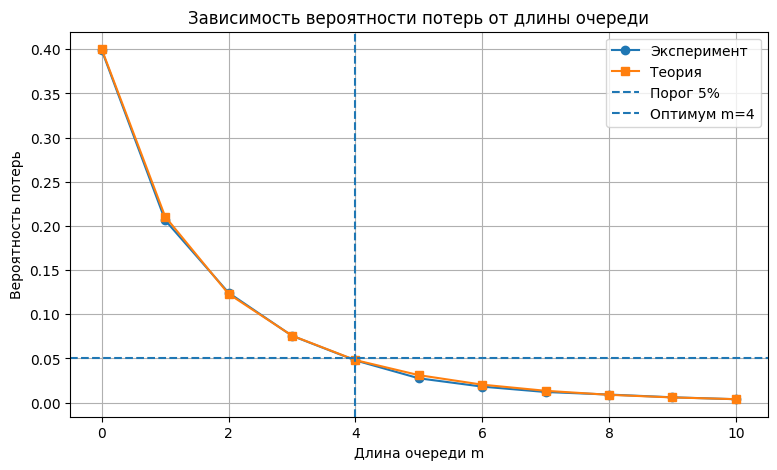

In [9]:

plt.figure()
plt.plot(comparison_df["m"], comparison_df["P_loss_exp"], marker="o", label="Эксперимент")
plt.plot(comparison_df["m"], comparison_df["P_loss_theory"], marker="s", label="Теория")
plt.axhline(loss_threshold, linestyle="--", label="Порог 5%")
if optimal_m is not None:
    plt.axvline(optimal_m, linestyle="--", label=f"Оптимум m={optimal_m}")
plt.xlabel("Длина очереди m")
plt.ylabel("Вероятность потерь")
plt.title("Зависимость вероятности потерь от длины очереди")
plt.grid(True)
plt.legend()
plt.show()


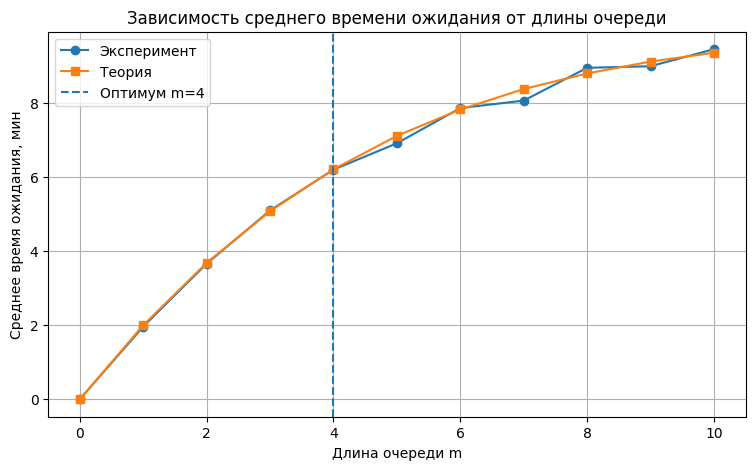

In [10]:

plt.figure()
plt.plot(comparison_df["m"], comparison_df["Wq_min_exp"], marker="o", label="Эксперимент")
plt.plot(comparison_df["m"], comparison_df["Wq_min_theory"], marker="s", label="Теория")
if optimal_m is not None:
    plt.axvline(optimal_m, linestyle="--", label=f"Оптимум m={optimal_m}")
plt.xlabel("Длина очереди m")
plt.ylabel("Среднее время ожидания, мин")
plt.title("Зависимость среднего времени ожидания от длины очереди")
plt.grid(True)
plt.legend()
plt.show()



## Анализ результатов

По результатам расчётов и моделирования можно сделать следующие выводы:

1. При увеличении длины очереди $m$ вероятность потерь снижается, так как система может принять больше клиентов до наступления отказа.
2. Экспериментальные значения близки к теоретическим, что подтверждает корректность модели.
3. При увеличении $m$ среднее время ожидания растёт, поскольку больше клиентов остаётся в системе и ожидает обслуживания.
5. Оптимальным считается минимальное значение $m$, при котором вероятность потерь не превышает 5%.

## Вывод

В ходе лабораторной работы была исследована система массового обслуживания $M/M/1/m$, моделирующая пункт выдачи заказов с одним оператором и ограниченной очередью.

Для параметров:
- $\lambda = 8$ заявок/час;
- $\mu = 12$ заявок/час;

получено, что минимальная длина очереди, удовлетворяющая условию $P_{\text{loss}} \le 0.05$, обеспечивает сбалансированную работу системы: потери остаются в допустимых пределах, а среднее время ожидания составляет несколько минут, что допустимо для реального ПВЗ.

Таким образом, увеличение скорости обслуживания позволяет добиться более реалистичных характеристик системы без чрезмерного увеличения длины очереди.
